In [2]:
import pandas as pd
import os

DATA_PATH = "../data/raw"

files = [f for f in os.listdir(DATA_PATH) if f.endswith(".csv")]

print("Gefundene Dateien:")
for file in files:
    print(file)

Gefundene Dateien:
EPL_2020_21.csv
EPL_2021_22.csv
EPL_2022_23.csv
EPL_2023_24.csv
EPL_2024_25.csv


In [3]:
dfs = []

for file in files:
    df = pd.read_csv(os.path.join(DATA_PATH, file))
    df["Season"] = file.replace(".csv", "")
    dfs.append(df)

matches = pd.concat(dfs, ignore_index=True)

print("Datensatzgröße:", matches.shape)

matches.head()

Datensatzgröße: (1900, 163)


C:\Users\HP\AppData\Local\Temp\ipykernel_34860\1987640645.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Season"] = file.replace(".csv", "")


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
matches.info()


<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Columns: 163 entries, Div to LBCA
dtypes: float64(138), int64(16), str(9)
memory usage: 2.4 MB


In [5]:
matches.columns.tolist()  #zeigt alle Spaltennamen an

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BWH',
 'BWD',
 'BWA',
 'IWH',
 'IWD',
 'IWA',
 'PSH',
 'PSD',
 'PSA',
 'WHH',
 'WHD',
 'WHA',
 'VCH',
 'VCD',
 'VCA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BWCH',
 'BWCD',
 'BWCA',
 'IWCH',
 'IWCD',
 'IWCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'WHCH',
 'WHCD',
 'WHCA',
 'VCCH',
 'VCCD',
 'VCCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'AvgCD',
 'AvgCA',
 'B365C>2.5',
 'B365C<2.5',
 'PC>2.5',
 'PC<2.5',
 'MaxC>2.5',
 'MaxC<2.5',
 'AvgC>2.5',
 'AvgC<2.5',
 'AHCh',
 'B365CAHH',
 'B365CAHA',
 'PCAHH',
 'PCAHA',
 'MaxCAHH',
 'MaxCAHA

Modell soll lernen ob beide Manschaften mindestens ein Tor schießen

In [6]:
matches["BTTS"] = ((matches["FTHG"] > 0) & (matches["FTAG"] > 0)).astype(int)

matches[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "BTTS"]].head(10)

C:\Users\HP\AppData\Local\Temp\ipykernel_34860\1603119491.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matches["BTTS"] = ((matches["FTHG"] > 0) & (matches["FTAG"] > 0)).astype(int)


,HomeTeam,AwayTeam,FTHG,FTAG,BTTS
0,Brentford,Arsenal,2,0,0
1,Man United,Leeds,5,1,1
2,Burnley,Brighton,1,2,1
3,Chelsea,Crystal Palace,3,0,0
4,Everton,Southampton,3,1,1
5,Leicester,Wolves,1,0,0
6,Watford,Aston Villa,3,2,1
7,Norwich,Liverpool,0,3,0
8,Newcastle,West Ham,2,4,1
9,Tottenham,Man City,1,0,0


Analysieren der Zielvariable

In [7]:
matches["BTTS"].value_counts()

BTTS
1    1051
0     849
Name: count, dtype: int64

In [8]:
matches["BTTS"].value_counts(normalize=True) * 100

BTTS
1    55.315789
0    44.684211
Name: proportion, dtype: float64

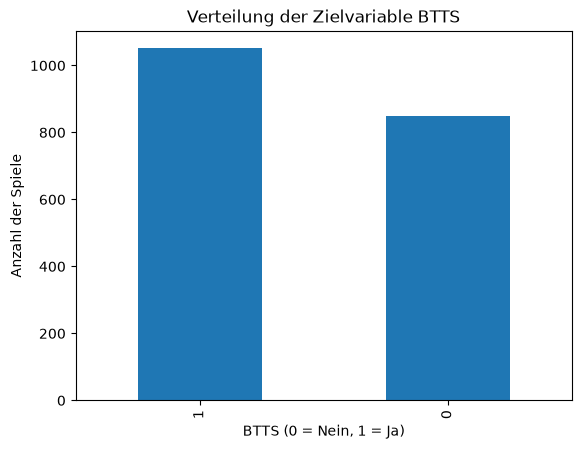

In [9]:
import matplotlib.pyplot as plt

matches["BTTS"].value_counts().plot(kind="bar")

plt.title("Verteilung der Zielvariable BTTS")
plt.xlabel("BTTS (0 = Nein, 1 = Ja)")
plt.ylabel("Anzahl der Spiele")

plt.show()

Erstes Feature erstellen

In [10]:
# anschauen der Daten, die wir für das Modell verwenden werden

matches[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "BTTS"]].head(10)


,HomeTeam,AwayTeam,FTHG,FTAG,BTTS
0,Brentford,Arsenal,2,0,0
1,Man United,Leeds,5,1,1
2,Burnley,Brighton,1,2,1
3,Chelsea,Crystal Palace,3,0,0
4,Everton,Southampton,3,1,1
5,Leicester,Wolves,1,0,0
6,Watford,Aston Villa,3,2,1
7,Norwich,Liverpool,0,3,0
8,Newcastle,West Ham,2,4,1
9,Tottenham,Man City,1,0,0


Sortieren der Spiel chronologisch - wichtig, nie Daten aus der Zukunft verwenden

In [11]:
matches["Date"] = pd.to_datetime(matches["Date"], dayfirst=True)

matches = matches.sort_values("Date")

matches.reset_index(drop=True, inplace=True)

matches[["Date", "HomeTeam", "AwayTeam"]].head()

,Date,HomeTeam,AwayTeam
0,2021-08-13,Brentford,Arsenal
1,2021-08-14,Man United,Leeds
2,2021-08-14,Burnley,Brighton
3,2021-08-14,Chelsea,Crystal Palace
4,2021-08-14,Everton,Southampton
